In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn import ensemble
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [89]:
df = pd.read_csv('dataset.csv',index_col=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

Видим, что в столбцах не везде одинаковые значение (114000 и 113999). Значит у нас есть какое-то нулевое значение. Его надо убрать

In [90]:
#Находим не заполненную строчку
bad_idx = df[df['artists'].isnull()].index
#Выводим номер этой строчки, чтобы просто удалить ее через этот номер
print(bad_idx)


Index([65900], dtype='int64')


In [91]:
df = df.drop(bad_idx)

In [92]:
#Смотрим какие уникальные значения встречаются в каждом столбце. Где значений мало, значит там либо разные классы, либо какое-то булевое значение(0 или 1)
for i in df.columns:
    print(i,len(df[i].unique()), sep=' - ')

track_id - 89740
artists - 31437
album_name - 46589
track_name - 73608
popularity - 101
duration_ms - 50696
explicit - 2
danceability - 1174
energy - 2083
key - 12
loudness - 19480
mode - 2
speechiness - 1489
acousticness - 5061
instrumentalness - 5346
liveness - 1722
valence - 1790
tempo - 45652
time_signature - 5
track_genre - 114


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113999 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        113999 non-null  int64  
 5   duration_ms       113999 non-null  int64  
 6   explicit          113999 non-null  bool   
 7   danceability      113999 non-null  float64
 8   energy            113999 non-null  float64
 9   key               113999 non-null  int64  
 10  loudness          113999 non-null  float64
 11  mode              113999 non-null  int64  
 12  speechiness       113999 non-null  float64
 13  acousticness      113999 non-null  float64
 14  instrumentalness  113999 non-null  float64
 15  liveness          113999 non-null  float64
 16  valence           113999 

В столбце Dtype видим значения object(не просто число, а ссылочный тип), bool(логический тип. Либо ложь, либо истина). Это не числовые значения в чистом виде. А для обучения модели нам нужны числа. Поэтому мы удалим их. Также мы удалим столбцы mode, key и time_signature (они принимают 2, 12 и 5 различных значений)(Смотри таблицу с уникальными значениями. Она чуть выше). 

In [94]:
df.columns
#Удаляем не подходящие столбцы
df = df.drop(columns = ['track_id', 'artists', 'album_name', 'track_name', 'time_signature', 'explicit', 'mode','track_genre', 'key'])
df.head(10)

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,73,230666,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.7150,87.917
1,55,149610,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.2670,77.489
2,57,210826,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.1200,76.332
3,71,201933,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.1430,181.740
4,82,198853,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.1670,119.949
5,58,214240,0.688,0.4810,-8.807,0.1050,0.2890,0.000000,0.1890,0.6660,98.017
6,74,229400,0.407,0.1470,-8.822,0.0355,0.8570,0.000003,0.0913,0.0765,141.284
7,80,242946,0.703,0.4440,-9.331,0.0417,0.5590,0.000000,0.0973,0.7120,150.960
8,74,189613,0.625,0.4140,-8.700,0.0369,0.2940,0.000000,0.1510,0.6690,130.088
9,56,205594,0.442,0.6320,-6.770,0.0295,0.4260,0.004190,0.0735,0.1960,78.899


In [95]:
#Необходимо привести стандартизацию, так как значение duration_ms принимает слишком большое
#количественное значение, что может повлиять на обучение модели. Модели видит большие значения и посчитает, что этот признак важнее,
#чем может оказаться на самом деле
df['duration_norm'] = MinMaxScaler().fit_transform(df[['duration_ms']])
del df['duration_ms']


df.describe()

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_norm
count,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,0.566801,0.641383,-8.258950,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,0.041969
std,22.304959,0.173543,0.251530,5.029357,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.020521
min,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,0.456000,0.472000,-10.013000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,0.031648
50%,35.000000,0.580000,0.685000,-7.004000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,0.039077
75%,50.000000,0.695000,0.854000,-5.003000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,0.048371
max,100.000000,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,1.000000


array([[<Axes: title={'center': 'popularity'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>],
       [<Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'acousticness'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'valence'}>],
       [<Axes: title={'center': 'tempo'}>,
        <Axes: title={'center': 'duration_norm'}>, <Axes: >]],
      dtype=object)

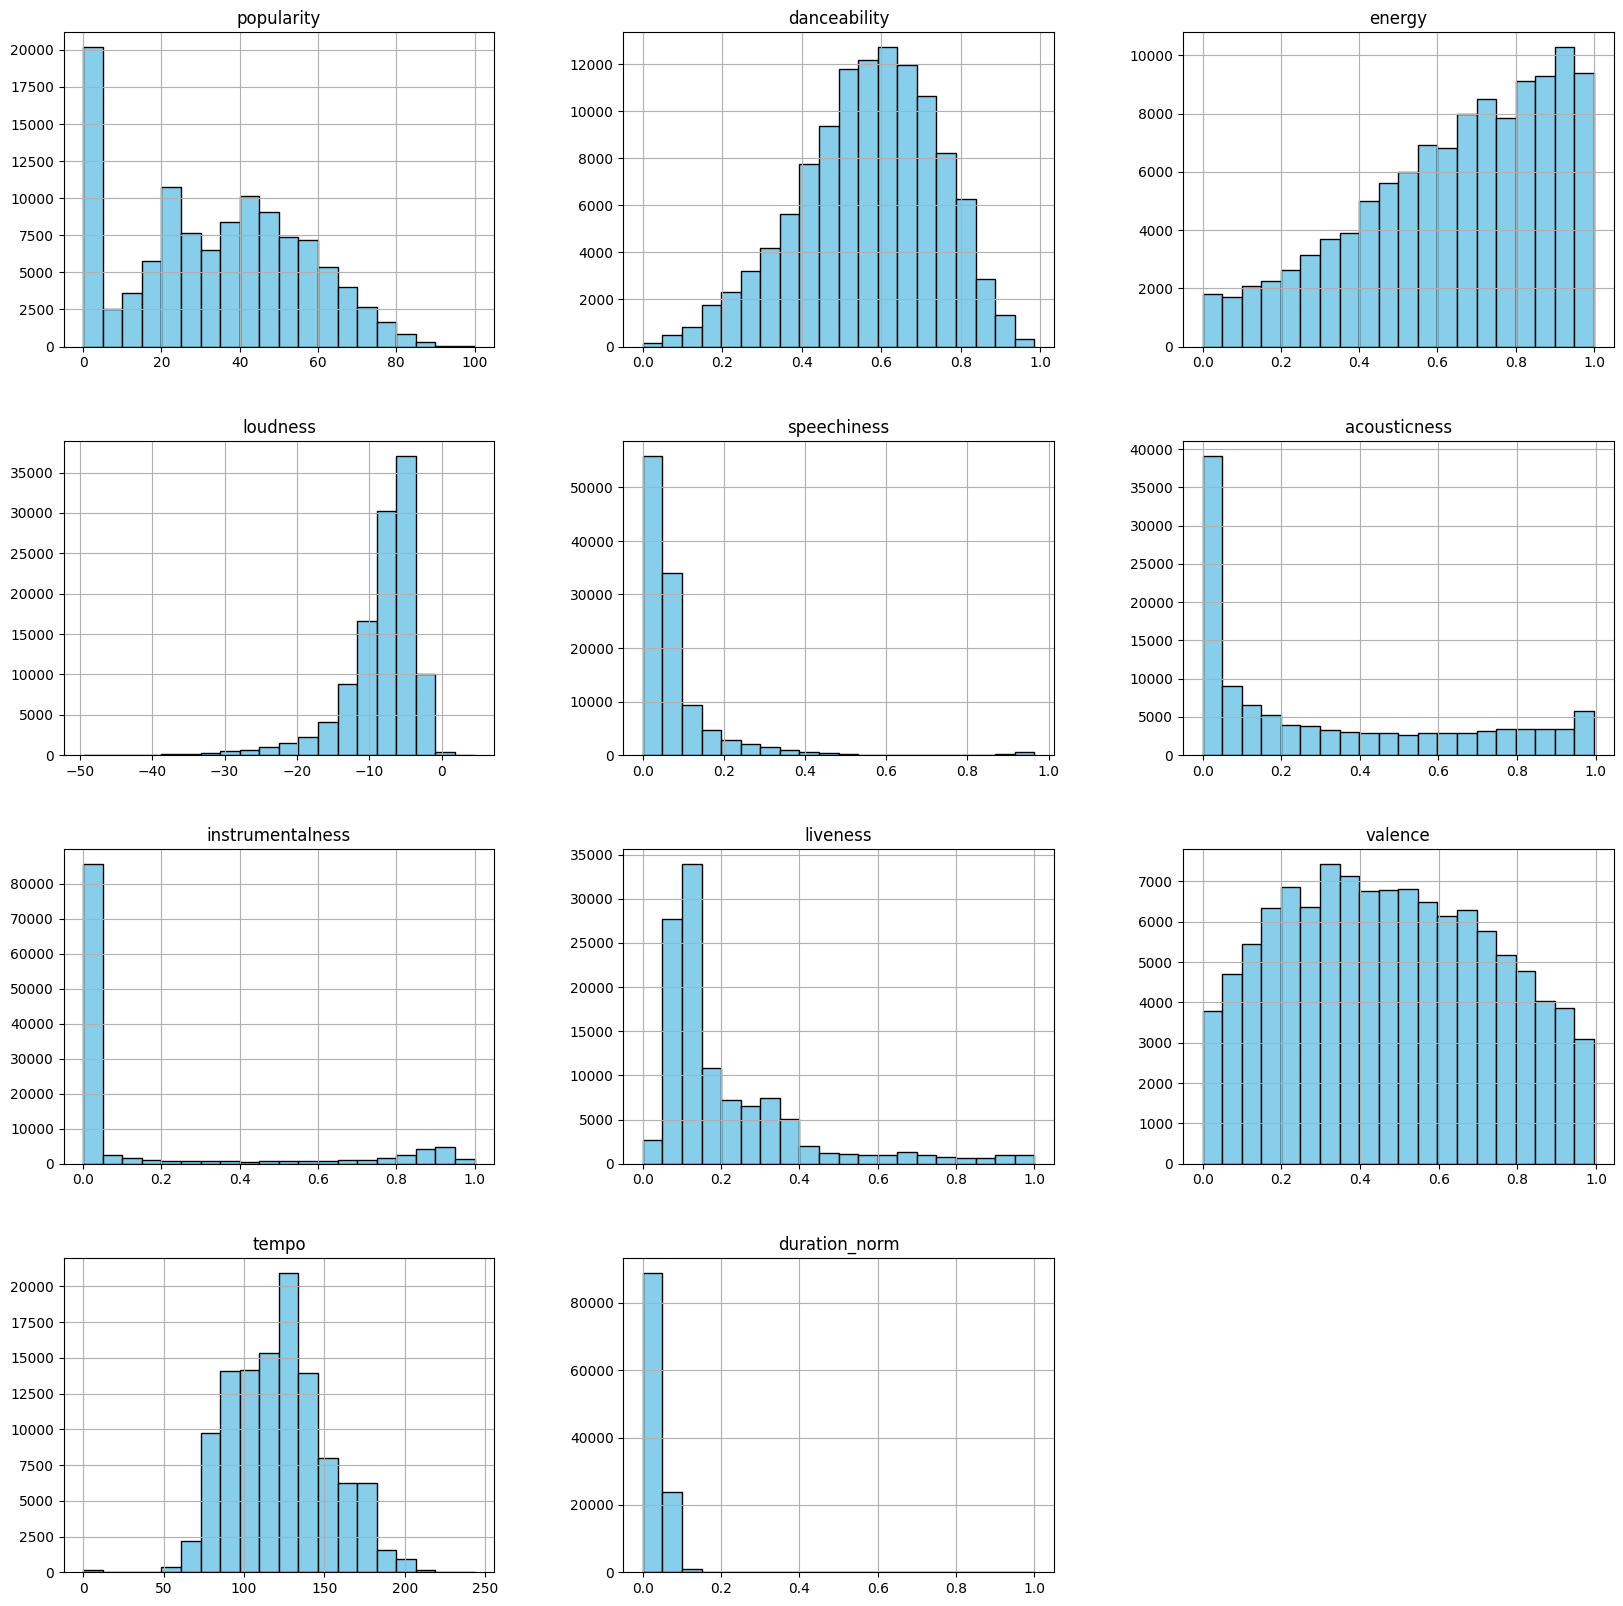

In [96]:
df.select_dtypes(['int64','float64']).hist(bins=20,           # количество столбцов в гистограмме
    figsize=(20, 20),  # размер всей фигуры
     # расположение графиков, подберите под кол-во столбцов
    color='skyblue',
    edgecolor='black'
)

Как понять, что данные принимают нормальные значения? Нужно чтобы их распределение было близким к нормальному(погугли, если не знаешь).
Из графиков видно, что не все графики выглядят как нормальное распределение. Мы не все можем поправить(по крайней мере я не знаю как), но мы точно можем убрать пик слева на самом первом графике(popularity), а также на графике (tempo)

In [97]:
# Фильтрация
df = df[df['popularity'] > 5].copy()
df = df[df['tempo'] > 20].copy()

array([[<Axes: title={'center': 'popularity'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>],
       [<Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'acousticness'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'valence'}>],
       [<Axes: title={'center': 'tempo'}>,
        <Axes: title={'center': 'duration_norm'}>, <Axes: >]],
      dtype=object)

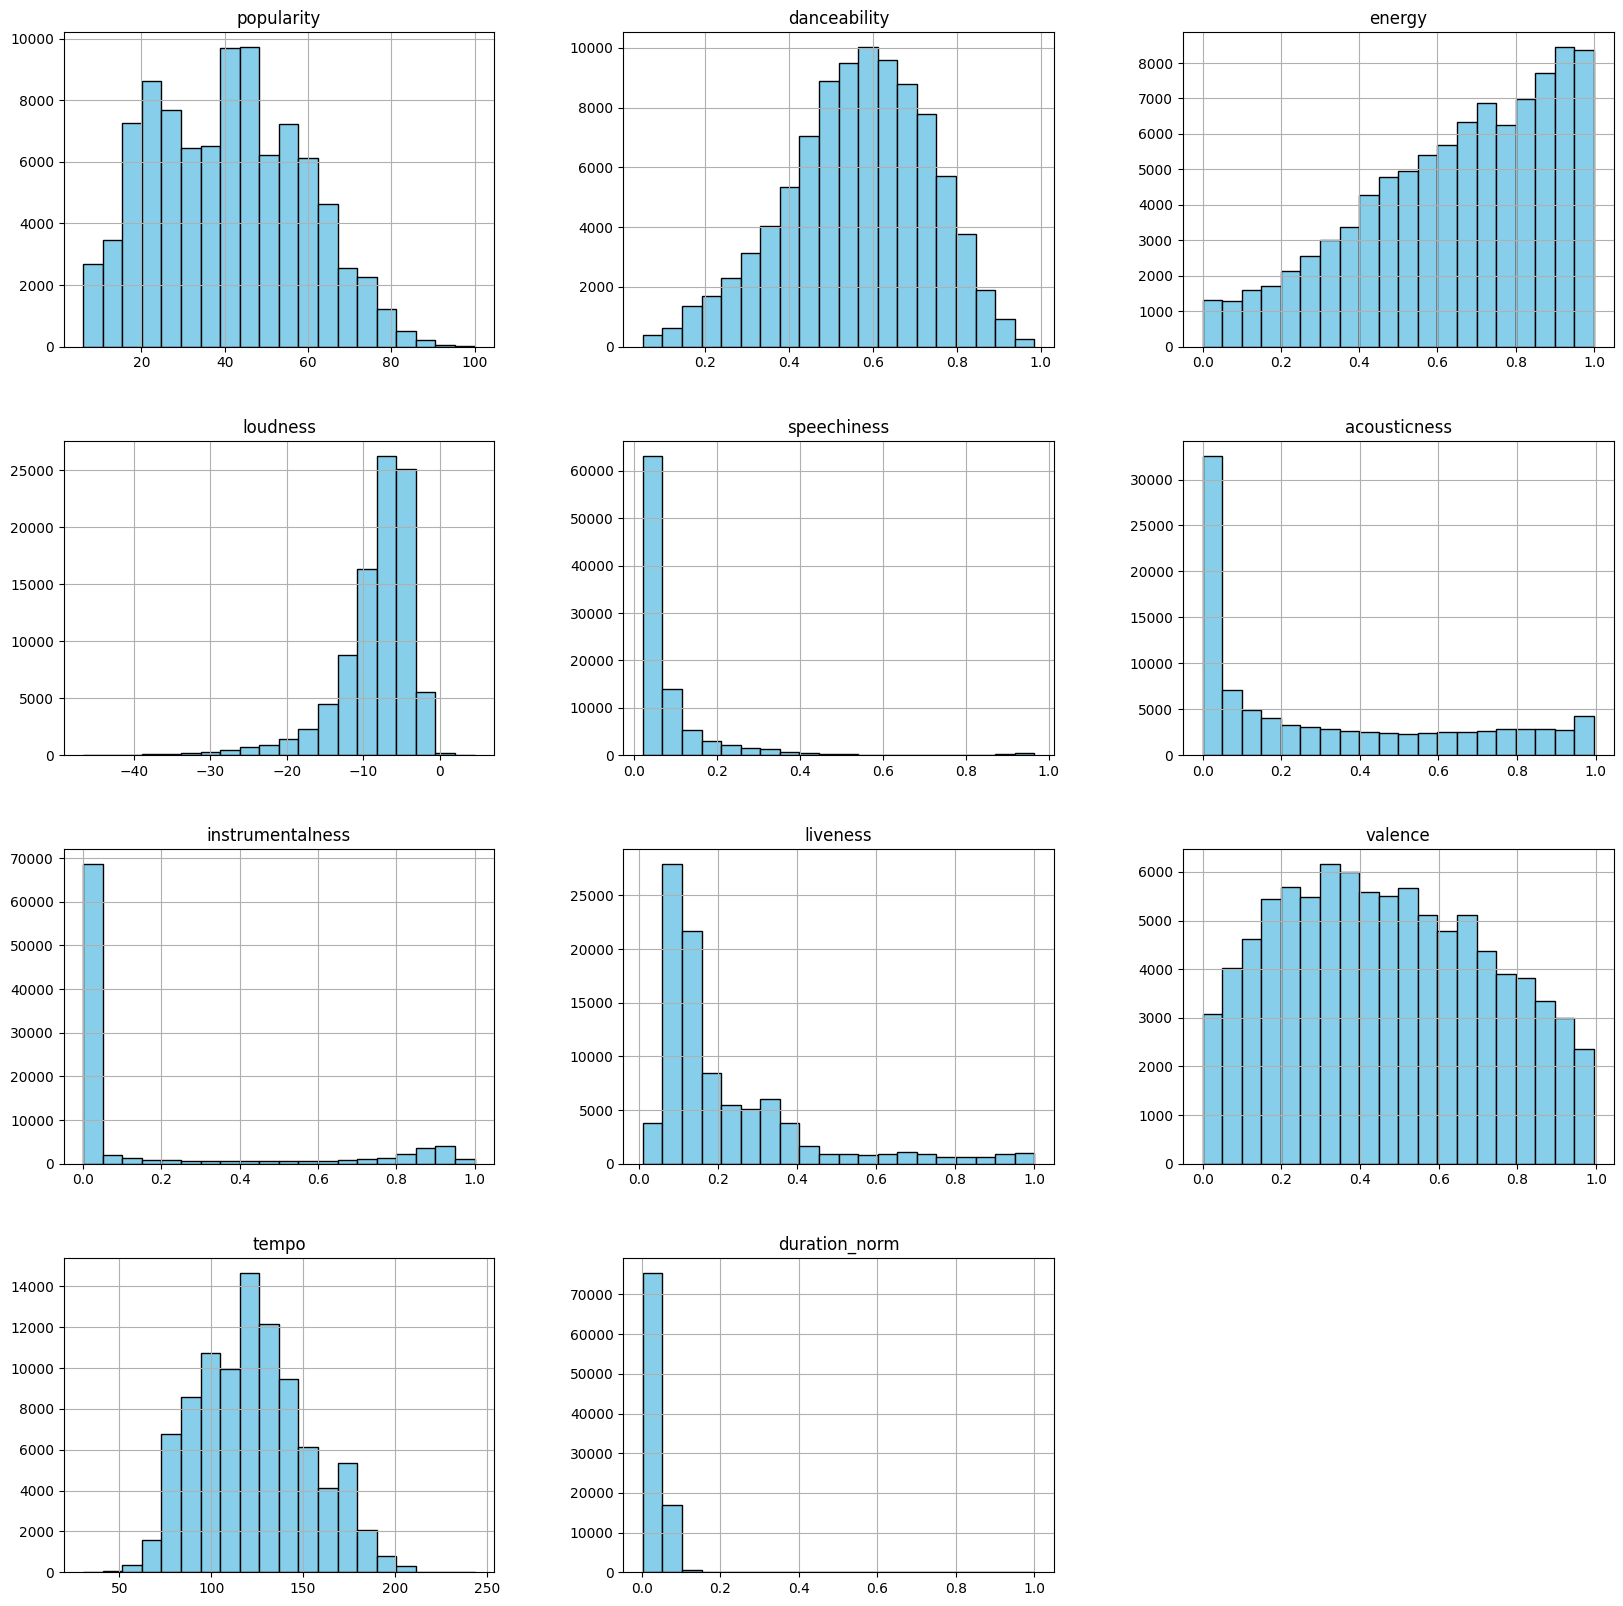

In [98]:
df.select_dtypes(['int64','float64']).hist(bins=20,           # количество столбцов в гистограмме
    figsize=(20, 20),  # размер всей фигуры
     # расположение графиков, подберите под кол-во столбцов
    color='skyblue',
    edgecolor='black'
)
#Из полученных диаграмм видем, что у графиков разный масштаб. => Необходимо привести стандартизацию
#Снова смотрим и сравниваем

Важность признаков
             Feature  Importance
6   instrumentalness    0.112143
5       acousticness    0.106215
3           loudness    0.101755
4        speechiness    0.100496
1       danceability    0.099191
8            valence    0.098592
2             energy    0.092156
9              tempo    0.091365
7           liveness    0.082030
0        duration_ms    0.058948
10     duration_norm    0.057108


C:\Users\Ig Al\AppData\Local\Temp\ipykernel_18668\1341469017.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


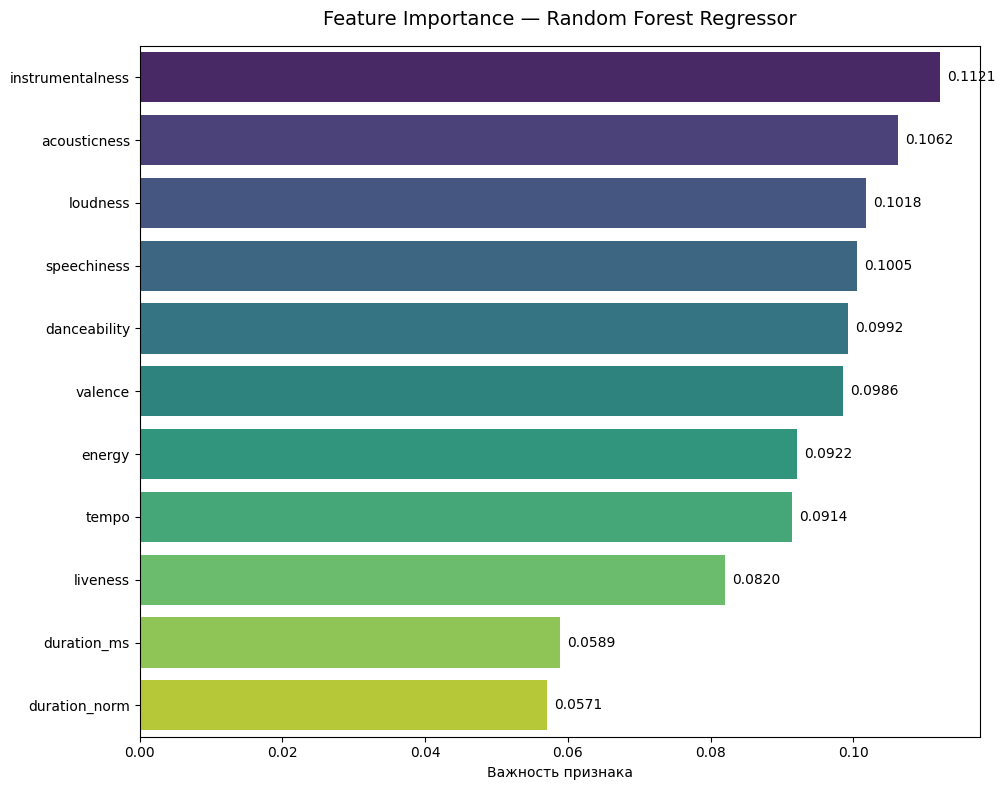

In [83]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ====================== Feature Importance ======================

# Получаем важность признаков
importances = rf_model.feature_importances_
feature_names = train_points.columns

# Создаём DataFrame
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)


print("Важность признаков")
print(feature_imp_df.head(11))

# ====================== График ======================
plt.figure(figsize=(10, 8))

top_n = 12  # сколько признаков показывать
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_imp_df.head(top_n),
    palette='viridis'
)

plt.title('Feature Importance — Random Forest Regressor', fontsize=14, pad=15)
plt.xlabel('Важность признака')
plt.ylabel('')
plt.tight_layout()

# Добавляем подписи значений на столбцы
for i, v in enumerate(feature_imp_df['Importance'].head(top_n)):
    plt.text(v + 0.001, i, f"{v:.4f}", va='center')

plt.show()

In [99]:
df.to_csv('dataset_mod1.csv')

In [100]:
#Начинаем обучать модель
values = df['popularity']
points = df.drop(['popularity'], axis=1)
train_points, test_points, train_values, test_values = train_test_split(points, values, test_size = 0.2)


In [101]:
rf_model = ensemble.RandomForestRegressor(n_estimators=10)
rf_model.fit(train_points, train_values)
test_predict_rf = rf_model.predict(test_points)
print(mean_absolute_error(test_values, test_predict_rf))

10.647997281451302


Ошибка равна 10.64, то есть модель отклоняется от реального значения в среднем на 10. Для целевой метрики popularity, которая у нас от 0 и до 100, это нормально.
